In [4]:
import networkx as nx
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Absolute Center: (0, 13)
M: {(0, 13): 1, (0, 9): 1, (1, 2): 1, (1, 6): 1, (2, 11): 1, (3, 4): 1, (3, 8): 1, (4, 5): 1, (5, 10): 1, (6, 7): 1, (7, 8): 1, (9, 10): 1, (11, 12): 1, (12, 13): 1, (0, 1): 0, (2, 3): 0, (4, 13): 0, (5, 6): 0, (7, 12): 0, (8, 9): 0, (10, 11): 0}
Matchings: {2: [(2, 3)], 3: [(3, 8)], 5: [(5, 10)], 6: [(5, 6)], 7: [(6, 7)], 8: [(7, 8)], 10: [(10, 11)], 11: [(2, 11)]}


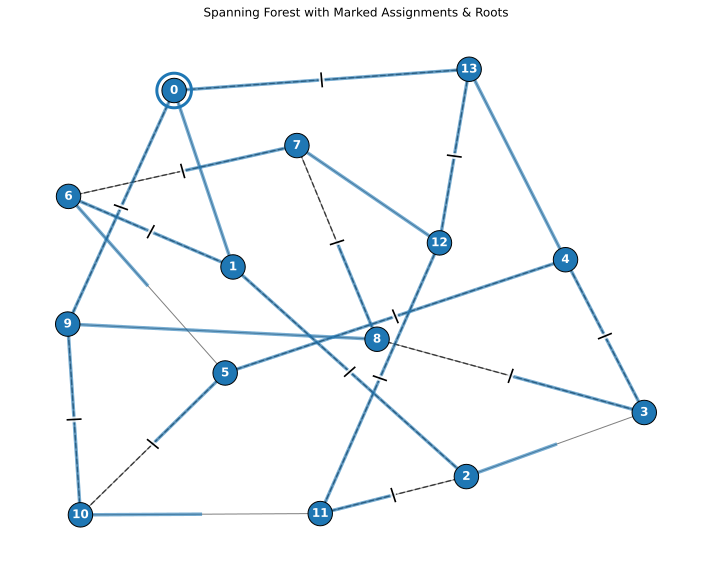

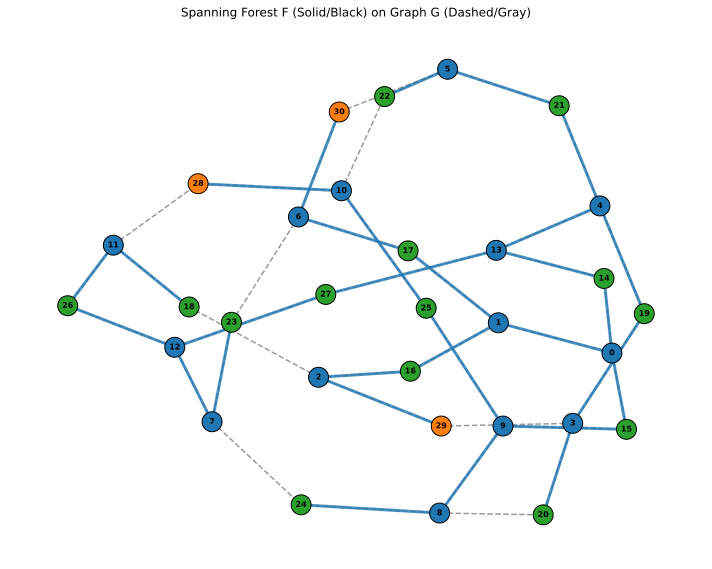

In [5]:
from spidercat.circuit_extraction import expand_graph_and_forest, find_mdst

from spidercat.draw import draw_forest_on_graph

grf, _, M, _ = load_solution_triplet(14, 5, 1)
tree, center, radius = find_mdst(grf)
print(f"Absolute Center: {center}")

matchings = match_forest_leaves_to_marked_edges(grf, tree, M)
print(f"M: {M}")
print(f"Matchings: {matchings}")
draw_spanning_forest_solution(grf, tree, M, matchings, {0: center[0] if isinstance(center, tuple) else center}, figsize=(10, 8))
G, F = expand_graph_and_forest(grf, tree, M, matchings)

draw_forest_on_graph(G, F)


=== Starting Elegant Extraction (BFS) ===
Init Root 0 (Tree 0) -> Q0
[(0, 0)]
  Node 0 -> Branch 14: Spawned CNOT Q0 -> Q1
  Node 0 -> Branch 1: Spawned CNOT Q0 -> Q2
  Node 0 -> Primary 15 (Inherits Q0)
[(1, 2), (15, 0), (14, 1)]
  Node 1 -> Branch 16: Spawned CNOT Q2 -> Q3
  Node 1 -> Primary 17 (Inherits Q2)
[(16, 3), (17, 2), (15, 0), (14, 1)]
  Mark on 16: Spawned CNOT Q3 -> Q4
  Node 16 -> Primary 2 (Inherits Q3)
[(2, 3), (17, 2), (15, 0), (14, 1)]
  New flag initialised (2, 18): CNOT Q3 -> Q17
  Node 2 -> Primary 29 (Inherits Q3)
[(29, 3), (17, 2), (15, 0), (14, 1)]
  Node 29 assumes the role of a flag qubit for edge (3, 29) on Q3.
[(17, 2), (15, 0), (14, 1)]
  Mark on 17: Spawned CNOT Q2 -> Q5
  Node 17 -> Primary 6 (Inherits Q2)
[(6, 2), (15, 0), (14, 1)]
  New flag initialised (6, 23): CNOT Q2 -> Q18
  Node 6 -> Primary 30 (Inherits Q2)
[(30, 2), (15, 0), (14, 1)]
  Node 30 assumes the role of a flag qubit for edge (5, 30) on Q2.
[(15, 0), (14, 1)]
  Mark on 15: Spawned CNOT 

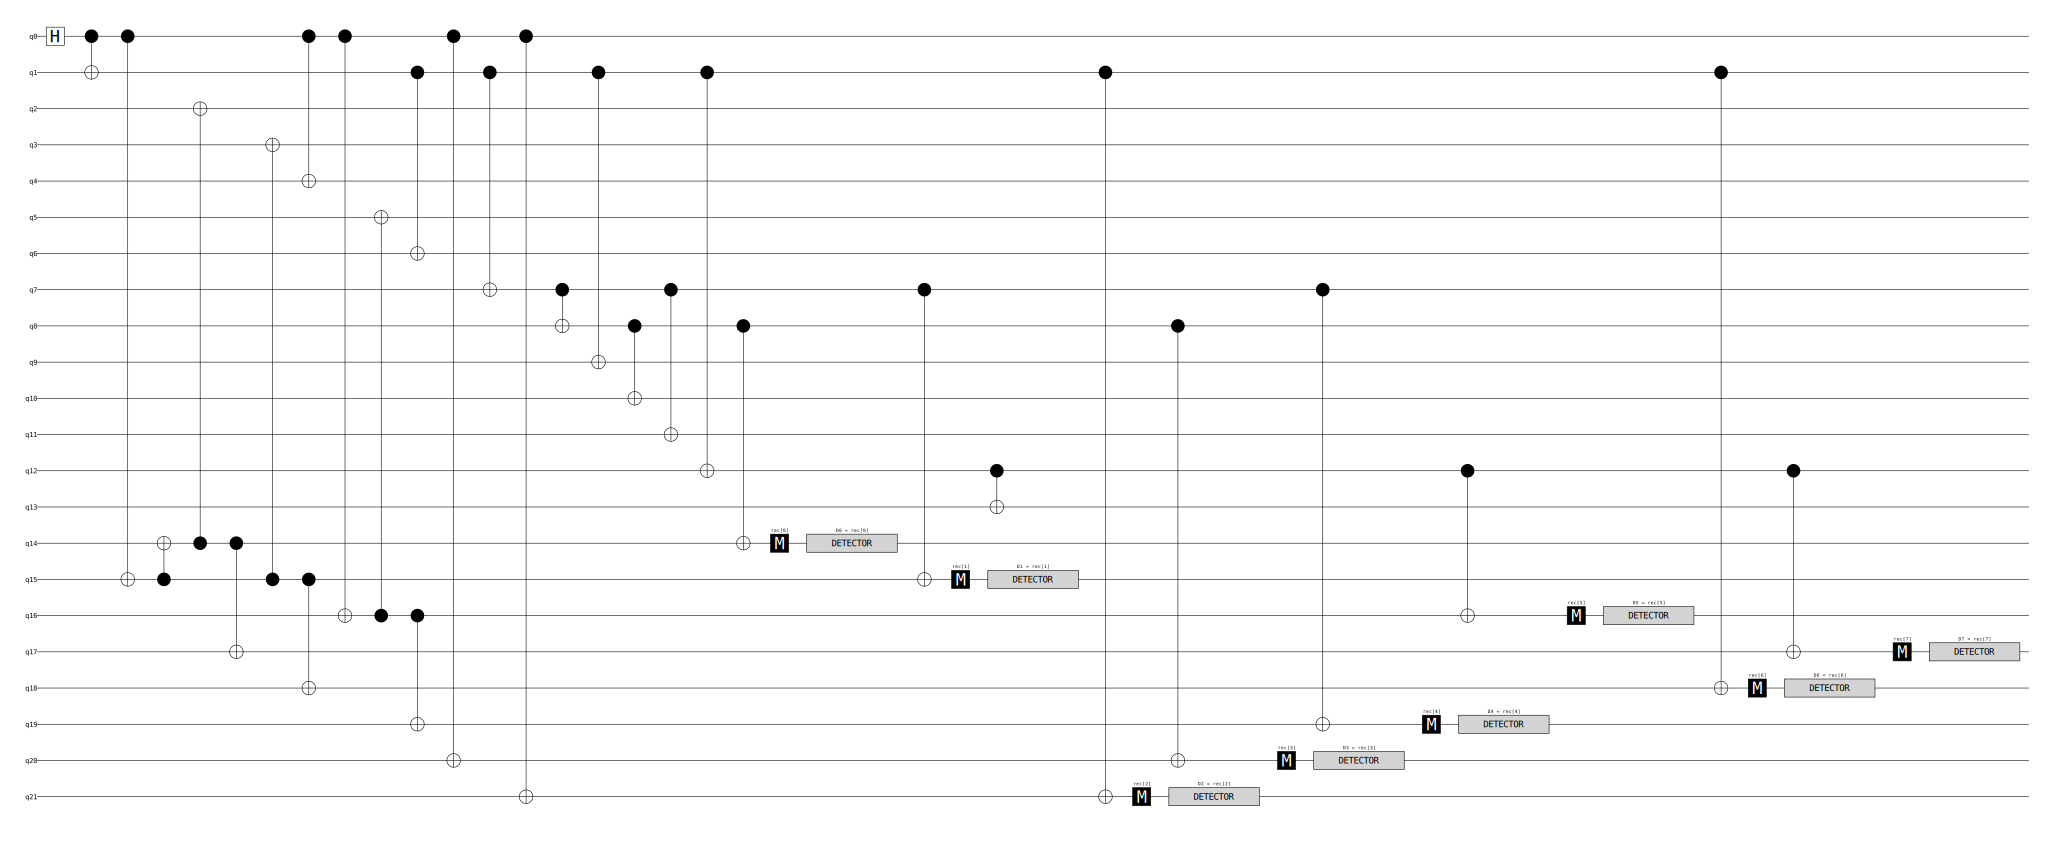

In [6]:
from spidercat.circuit_extraction import extract_circuit_rooted
roots = find_min_height_roots(F)
circ = extract_circuit_rooted(grf, tree, {0: center[0] if isinstance(center, tuple) else center}, M, matchings, verbose=True)
circ.diagram('timeline-svg')

In [9]:
circ.append("M", range(14))
circ.compile_sampler().sample(10)[:,-14:]

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         

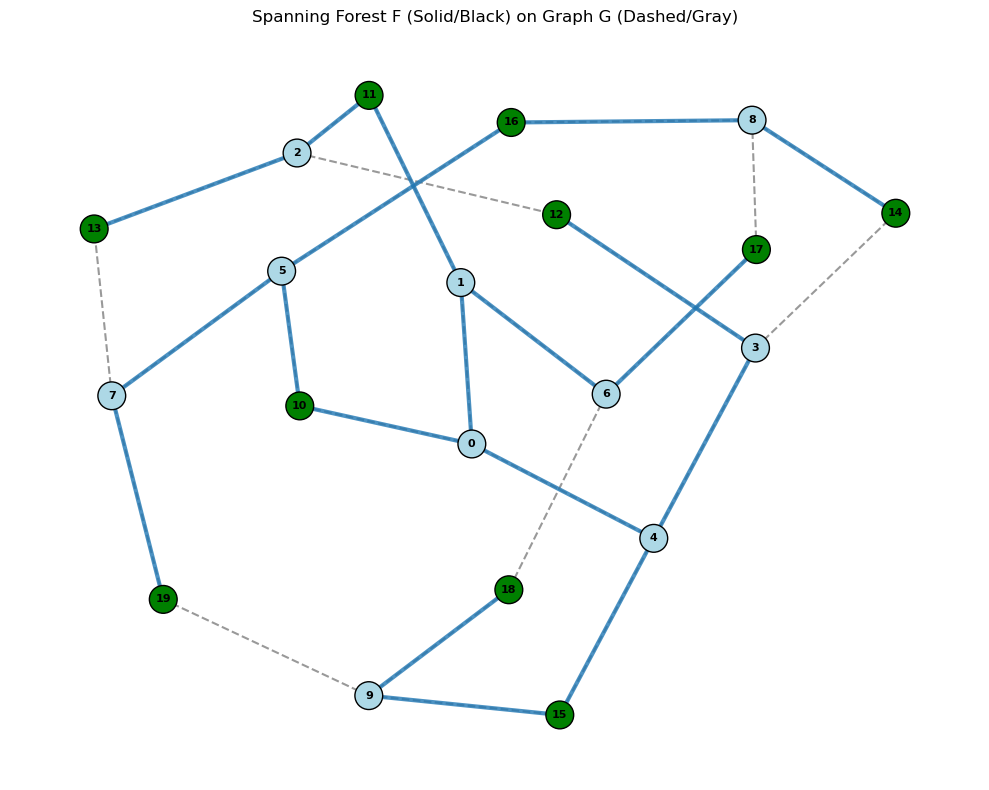

In [152]:
import networkx as nx
import matplotlib.pyplot as plt



visualize_forest_on_graph(G, F)